# Application laboratory: network state estimation as a Gaussian graphical model

Physical infrastructure often supplies the graph before any data are observed. In a linearized power-network model, node phase angles $\theta$ generate line flows proportional to angle differences. Gaussian measurement noise and a Gaussian prior therefore lead to a Gaussian posterior whose precision matrix is sparse and graph-structured.

The example below is intentionally small. It illustrates a principle that becomes central later: known physics determines much of the factorization, while data update uncertainty within that structure.

In [1]:
CHAPTER_DIR="ch11"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
# Five-bus DC-style network, bus 0 is the reference angle.
n=5; edges=[(0,1),(1,2),(1,3),(2,4),(3,4)]; b={e:1.0+0.3*k for k,e in enumerate(edges)}
true_theta=np.array([0.0,.13,.22,-.05,.08])
# measurements: all line flows plus noisy angle observations at buses 2 and 4
rows=[]; z=[]; sig=[]
for e in edges:
    i,j=e; row=np.zeros(n-1)
    if i!=0: row[i-1]+=b[e]
    if j!=0: row[j-1]-=b[e]
    rows.append(row); z.append(b[e]*(true_theta[i]-true_theta[j])); sig.append(.035)
for i in [2,4]:
    row=np.zeros(n-1); row[i-1]=1; rows.append(row); z.append(true_theta[i]); sig.append(.05)
Hmat=np.vstack(rows); z=np.array(z)+RNG.normal(scale=sig); Rinv=np.diag(1/np.array(sig)**2)
prior_prec=.15*np.eye(n-1)
J=prior_prec+Hmat.T@Rinv@Hmat; h=Hmat.T@Rinv@z
mu=np.linalg.solve(J,h); Sigma=np.linalg.inv(J)
post=np.r_[0,mu]; std=np.r_[0,np.sqrt(np.diag(Sigma))]
print('true angles     ',np.round(true_theta,3)); print('posterior means ',np.round(post,3))

true angles      [ 0.    0.13  0.22 -0.05  0.08]
posterior means  [ 0.     0.136  0.236 -0.043  0.093]


<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2133/1308236121.py:7: SyntaxWarning: invalid escape sequence '\p'
  i=np.arange(n); axes[1].errorbar(i,post,yerr=2*std,fmt='o',capsize=5,label='posterior mean $\pm 2\sigma$'); axes[1].scatter(i,true_theta,marker='x',s=80,label='true state'); axes[1].set_xticks(i,[rf'$\theta_{k}$' for k in i]); axes[1].set_ylabel('phase angle'); axes[1].set_title('Gaussian state estimation on the graph'); axes[1].legend(); axes[1].grid(axis='y',alpha=.25)
/tmp/ipykernel_2133/1440664098.py:38: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)


Saved ch11_05_network_state_estimation


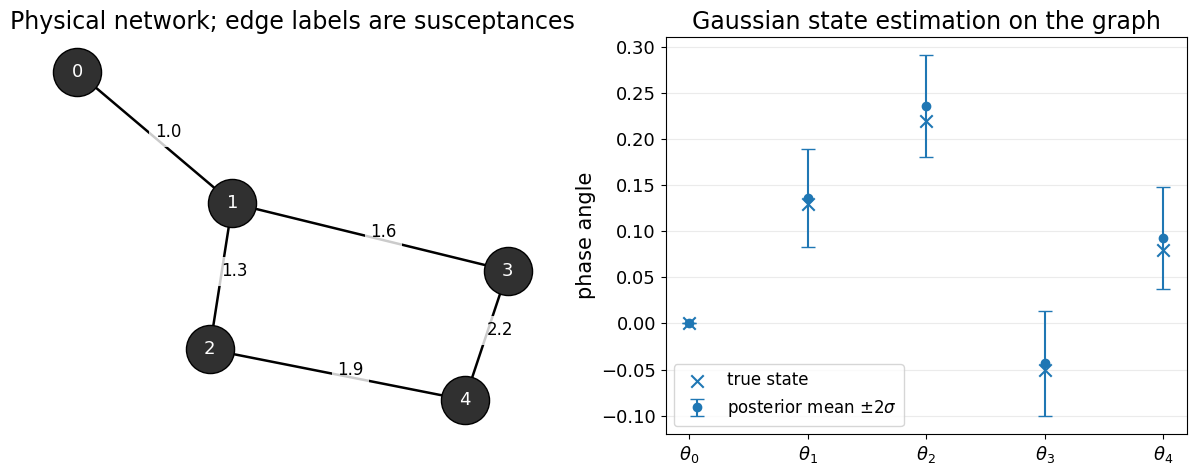

In [3]:
G=nx.Graph(); G.add_nodes_from(range(n)); G.add_edges_from(edges); pos=nx.spring_layout(G,seed=5)
fig,axes=plt.subplots(1,2,figsize=(12,5))
draw_dark_nodes(G,pos,labels={i:str(i) for i in range(n)},ax=axes[0],node_size=1200)
for e in edges:
    i,j=e; mid=(np.array(pos[i])+np.array(pos[j]))/2; axes[0].text(*mid,f'{b[e]:.1f}',fontsize=12,bbox=dict(facecolor='white',alpha=.8,edgecolor='none'))
axes[0].set_title('Physical network; edge labels are susceptances'); axes[0].axis('off')
i=np.arange(n); axes[1].errorbar(i,post,yerr=2*std,fmt='o',capsize=5,label='posterior mean $\pm 2\sigma$'); axes[1].scatter(i,true_theta,marker='x',s=80,label='true state'); axes[1].set_xticks(i,[rf'$\theta_{k}$' for k in i]); axes[1].set_ylabel('phase angle'); axes[1].set_title('Gaussian state estimation on the graph'); axes[1].legend(); axes[1].grid(axis='y',alpha=.25)
fig.tight_layout(); save_figure(fig,'ch11_05_network_state_estimation'); plt.show()

## Exercises

1. Remove one measurement at a time. Which measurement produces the largest posterior-variance increase?
2. Add a very weak line to the network and study the change in the posterior precision matrix.
3. Replace one Gaussian measurement by a gross outlier. Explain why the Gaussian model is fragile and propose a robust local factor.
4. Treat line status as an unknown binary variable. Explain how the model changes from purely Gaussian to a hybrid discrete--continuous graphical model.